# Обучение YOLO 11 для детекции шахматных фигур с поддержкой Multi-Object Tracking

Этот notebook содержит полный процесс обучения модели YOLO 11 для детекции шахматных фигур с поддержкой трекинга объектов.

## Особенности:
- Использование YOLO 11 (ultralytics)
- Поддержка Multi-Object Tracking (MOT)
- 12 классов: белые и черные фигуры (pawn, rook, bishop, knight, king, queen)
- Возможность дообучения на пользовательских датасетах


In [1]:
# Установка зависимостей
!pip install ultralytics
!pip install supervision
!pip install roboflow
!pip install pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 124.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
import os
import cv2
import numpy as np
from pathlib import Path
from ultralytics import YOLO
import yaml
from typing import List, Tuple
import json


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Настройка путей и параметров


In [3]:
# Настройки проекта
PROJECT_DIR = Path('/content/chess_pieces_yolo11')
DATASET_DIR = PROJECT_DIR / 'dataset'
MODELS_DIR = PROJECT_DIR / 'models'
RESULTS_DIR = PROJECT_DIR / 'results'

# Создание директорий
for dir_path in [PROJECT_DIR, DATASET_DIR, MODELS_DIR, RESULTS_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

# Параметры обучения
# ВАЖНО: Классы будут загружены автоматически из data.yaml от Roboflow!
# Сначала задаем путь к датасету (будет обновлен после распаковки)
DATASET_YAML_PATH = None  # Будет установлен после обработки датасета

# Временные значения (будут перезаписаны после загрузки data.yaml)
NUM_CLASSES = 13
CLASS_NAMES = []

def load_classes_from_yaml(yaml_path: Path) -> Tuple[int, List[str]]:
    """Загрузка классов из data.yaml от Roboflow"""
    if not yaml_path.exists():
        raise FileNotFoundError(f"data.yaml не найден: {yaml_path}")

    with open(yaml_path, 'r', encoding='utf-8') as f:
        config = yaml.safe_load(f)

    # Получаем классы из data.yaml
    names = config.get('names', [])

    # Преобразуем в список, если это словарь
    if isinstance(names, dict):
        class_names = [names[i] for i in sorted(names.keys())]
    elif isinstance(names, list):
        class_names = names
    else:
        raise ValueError(f"Неожиданный формат names в data.yaml: {type(names)}")

    num_classes = len(class_names)

    print(f"✓ Классы загружены из {yaml_path}")
    print(f"  Количество классов: {num_classes}")
    print(f"  Классы:")
    for i, name in enumerate(class_names):
        print(f"    {i}: {name}")

    return num_classes, class_names

# Параметры модели
MODEL_SIZE = 's'  # n, s, m, l, x (nano, small, medium, large, xlarge)
IMG_SIZE = 640
EPOCHS = 100
BATCH_SIZE = 32
PATIENCE = 50  # Early stopping patience

print(f"Проект создан: {PROJECT_DIR}")
print(f"Размер модели: {MODEL_SIZE}")
print(f"\n⚠ ВАЖНО: Классы будут загружены из data.yaml после обработки датасета!")
print(f"   Убедитесь, что запустили ячейку обработки датасета перед обучением.")


Проект создан: /content/chess_pieces_yolo11
Размер модели: s

⚠ ВАЖНО: Классы будут загружены из data.yaml после обработки датасета!
   Убедитесь, что запустили ячейку обработки датасета перед обучением.


## Подготовка датасета


### Вариант 2: Загрузка датасета из Roboflow (если используется)


In [4]:
# Обработка архива
import zipfile
import shutil

ARCHIVE_PATH = None

# Автоматический поиск архива
if ARCHIVE_PATH is None:
    content_dir = Path("/content")
    zip_files = list(content_dir.glob("*.zip"))
    if zip_files:
        ARCHIVE_PATH = str(zip_files[0])
        print(f"Найден архив: {ARCHIVE_PATH}")
    else:
        print("Архив не найден. Укажите путь: ARCHIVE_PATH = '/content/Chess Pieces.v24-416x416_aug.yolov11.zip'")
        ARCHIVE_PATH = None

if ARCHIVE_PATH and Path(ARCHIVE_PATH).exists():
    print(f"Обработка: {ARCHIVE_PATH}")

    temp_extract = DATASET_DIR.parent / "temp_extract"
    temp_extract.mkdir(exist_ok=True)

    print("Распаковка...")
    with zipfile.ZipFile(ARCHIVE_PATH, 'r') as zip_ref:
        zip_ref.extractall(temp_extract)

    # Поиск структуры
    extracted_dirs = list(temp_extract.rglob("train"))
    if not extracted_dirs:
        extracted_dirs = list(temp_extract.rglob("*train*"))

    if extracted_dirs:
        dataset_root = extracted_dirs[0].parent
        print(f"Найден датасет: {dataset_root}")

        # Создаем структуру
        (DATASET_DIR / 'train' / 'images').mkdir(parents=True, exist_ok=True)
        (DATASET_DIR / 'train' / 'labels').mkdir(parents=True, exist_ok=True)

        # Копируем файлы (valid создается только если есть в исходном датасете)
        for split in ['train', 'test']:
            split_dir = dataset_root / split
            if split_dir.exists():
                if (split_dir / 'images').exists():
                    (DATASET_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
                    shutil.copytree(split_dir / 'images', DATASET_DIR / split / 'images', dirs_exist_ok=True)
                if (split_dir / 'labels').exists():
                    (DATASET_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)
                    shutil.copytree(split_dir / 'labels', DATASET_DIR / split / 'labels', dirs_exist_ok=True)

        # Копируем valid только если он есть в исходном датасете
        valid_dir = dataset_root / 'valid'
        if valid_dir.exists():
            (DATASET_DIR / 'valid' / 'images').mkdir(parents=True, exist_ok=True)
            (DATASET_DIR / 'valid' / 'labels').mkdir(parents=True, exist_ok=True)
            if (valid_dir / 'images').exists():
                shutil.copytree(valid_dir / 'images', DATASET_DIR / 'valid' / 'images', dirs_exist_ok=True)
            if (valid_dir / 'labels').exists():
                shutil.copytree(valid_dir / 'labels', DATASET_DIR / 'valid' / 'labels', dirs_exist_ok=True)

        # Копируем YAML
        for yaml_file in list(dataset_root.glob("*.yaml")) + list(dataset_root.glob("*.yml")):
            shutil.copy(yaml_file, DATASET_DIR / yaml_file.name)

        shutil.rmtree(temp_extract)
        print(f"✓ Датасет обработан: {DATASET_DIR}")

        # Загружаем классы из data.yaml
        data_yaml_path = DATASET_DIR / 'data.yaml'
        if data_yaml_path.exists():
            NUM_CLASSES, CLASS_NAMES = load_classes_from_yaml(data_yaml_path)
            DATASET_YAML_PATH = data_yaml_path
            print(f"\n✓ Классы загружены! NUM_CLASSES={NUM_CLASSES}")
        else:
            print("⚠ data.yaml не найден в датасете")
    else:
        print("❌ Не найдена структура датасета в архиве")
else:
    print("⚠ Архив не найден")


Найден архив: /content/merged_new.zip
Обработка: /content/merged_new.zip
Распаковка...
Найден датасет: /content/chess_pieces_yolo11/temp_extract/merged_new
✓ Датасет обработан: /content/chess_pieces_yolo11/dataset
✓ Классы загружены из /content/chess_pieces_yolo11/dataset/data.yaml
  Количество классов: 12
  Классы:
    0: white-pawn
    1: white-rook
    2: white-bishop
    3: white-knight
    4: white-king
    5: white-queen
    6: black-pawn
    7: black-rook
    8: black-bishop
    9: black-king
    10: black-queen
    11: black-knight

✓ Классы загружены! NUM_CLASSES=12


In [5]:
# Проверка датасета
if (DATASET_DIR / 'train' / 'images').exists():
    train_images = len(list((DATASET_DIR / 'train' / 'images').glob('*')))
    train_labels = len(list((DATASET_DIR / 'train' / 'labels').glob('*')))
    val_images = len(list((DATASET_DIR / 'valid' / 'images').glob('*'))) if (DATASET_DIR / 'valid' / 'images').exists() else 0
    val_labels = len(list((DATASET_DIR / 'valid' / 'labels').glob('*'))) if (DATASET_DIR / 'valid' / 'labels').exists() else 0
    test_images = len(list((DATASET_DIR / 'test' / 'images').glob('*'))) if (DATASET_DIR / 'test' / 'images').exists() else 0

    print(f"✓ Датасет готов")
    print(f"  Train: {train_images} изображений, {train_labels} аннотаций")
    if val_images > 0:
        print(f"  Valid: {val_images} изображений, {val_labels} аннотаций")
    if test_images > 0:
        print(f"  Test:  {test_images} изображений")

    # Загружаем классы из data.yaml, если еще не загружены
    data_yaml_path = DATASET_DIR / 'data.yaml'
    if data_yaml_path.exists() and len(CLASS_NAMES) == 0:
        NUM_CLASSES, CLASS_NAMES = load_classes_from_yaml(data_yaml_path)
        DATASET_YAML_PATH = data_yaml_path
        print(f"\n✓ Классы загружены из data.yaml!")
else:
    print("❌ Датасет не найден. Загрузите архив и запустите ячейку выше")


✓ Датасет готов
  Train: 2534 изображений, 2534 аннотаций
  Valid: 620 изображений, 620 аннотаций
  Test:  312 изображений


## Проверка соответствия классов

**ВАЖНО:** Если модель делает неправильные предсказания, проверьте соответствие классов!


In [6]:
# Детальная проверка классов в датасете
print("="*60)
print("ПРОВЕРКА КЛАССОВ В ДАТАСЕТЕ")
print("="*60)

# Проверяем data.yaml от Roboflow
roboflow_yaml = DATASET_DIR / 'data.yaml'
if roboflow_yaml.exists():
    # Загружаем классы из data.yaml, если еще не загружены
    if len(CLASS_NAMES) == 0:
        NUM_CLASSES, CLASS_NAMES = load_classes_from_yaml(roboflow_yaml)
        DATASET_YAML_PATH = roboflow_yaml

    with open(roboflow_yaml, 'r') as f:
        roboflow_config = yaml.safe_load(f)

    roboflow_names = roboflow_config.get('names', {})

    # Преобразуем в список, если это словарь
    if isinstance(roboflow_names, dict):
        roboflow_classes = [roboflow_names[i] for i in sorted(roboflow_names.keys())]
    else:
        roboflow_classes = roboflow_names

    print(f"\n{'='*60}")
    print(f"Классы в data.yaml от Roboflow:")
    for i, name in enumerate(roboflow_classes):
        print(f"  {i}: {name}")

    print(f"\nКлассы в коде (CLASS_NAMES):")
    if len(CLASS_NAMES) > 0:
        for i, name in enumerate(CLASS_NAMES):
            print(f"  {i}: {name}")
    else:
        print("  ⚠ CLASS_NAMES пуст! Загрузите классы из data.yaml.")

    print(f"\n{'='*60}")
    if len(CLASS_NAMES) > 0 and roboflow_classes == CLASS_NAMES:
        print("✓✓✓ Порядок классов СОВПАДАЕТ! Все правильно!")
    elif len(CLASS_NAMES) == 0:
        print("⚠ CLASS_NAMES не загружен. Используйте load_classes_from_yaml()")
    else:
        print("⚠⚠⚠ КРИТИЧЕСКАЯ ПРОБЛЕМА: Порядок классов НЕ СОВПАДАЕТ!")
        print("\nЭто объясняет неправильные предсказания!")
        print("\nСравнение:")
        for i in range(max(len(roboflow_classes), len(CLASS_NAMES))):
            rf = roboflow_classes[i] if i < len(roboflow_classes) else "—"
            code = CLASS_NAMES[i] if i < len(CLASS_NAMES) else "—"
            match = "✓" if rf == code else "✗"
            print(f"  {i}: {rf:20s} vs {code:20s} {match}")
else:
    print("⚠ data.yaml не найден в датасете")
    print("Проверьте структуру датасета")


ПРОВЕРКА КЛАССОВ В ДАТАСЕТЕ

Классы в data.yaml от Roboflow:
  0: white-pawn
  1: white-rook
  2: white-bishop
  3: white-knight
  4: white-king
  5: white-queen
  6: black-pawn
  7: black-rook
  8: black-bishop
  9: black-king
  10: black-queen
  11: black-knight

Классы в коде (CLASS_NAMES):
  0: white-pawn
  1: white-rook
  2: white-bishop
  3: white-knight
  4: white-king
  5: white-queen
  6: black-pawn
  7: black-rook
  8: black-bishop
  9: black-king
  10: black-queen
  11: black-knight

✓✓✓ Порядок классов СОВПАДАЕТ! Все правильно!


## Создание конфигурационного файла датасета


In [7]:
def create_dataset_yaml(dataset_path: Path, class_names: List[str]) -> Path:
    """Создание YAML файла конфигурации датасета"""
    yaml_path = dataset_path / 'dataset.yaml'

    config = {
        'path': str(dataset_path.absolute()),
        'train': 'train/images',
        'nc': len(class_names),
        'names': {i: name for i, name in enumerate(class_names)}
    }

    # YOLO 11 требует наличие 'val' в YAML всегда
    # Если есть valid - используем его, иначе test, иначе train (YOLO автоматически разделит)
    if (dataset_path / 'valid' / 'images').exists():
        config['val'] = 'valid/images'
    elif (dataset_path / 'test' / 'images').exists():
        config['val'] = 'test/images'
    else:
        config['val'] = 'train/images'  # YOLO автоматически создаст валидационный набор

    # Добавляем test только если папка существует
    if (dataset_path / 'test' / 'images').exists():
        config['test'] = 'test/images'

    with open(yaml_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)

    print(f"Конфигурация датасета создана: {yaml_path}")
    print(f"Конфигурация:\n{yaml.dump(config, default_flow_style=False)}")

    return yaml_path

# Проверка соответствия классов
def check_class_mapping(dataset_path: Path, expected_classes: List[str]):
    """Проверка соответствия классов в датасете"""
    roboflow_yaml = dataset_path / 'roboflow_data.yaml'
    if roboflow_yaml.exists():
        with open(roboflow_yaml, 'r') as f:
            roboflow_config = yaml.safe_load(f)
        roboflow_classes = roboflow_config.get('names', {})
        if isinstance(roboflow_classes, dict):
            roboflow_classes = [roboflow_classes[i] for i in sorted(roboflow_classes.keys())]
        print(f"\nКлассы в датасете Roboflow: {roboflow_classes}")
        print(f"Ожидаемые классы: {expected_classes}")

        if len(roboflow_classes) == len(expected_classes):
            if roboflow_classes == expected_classes:
                print("✓ Порядок классов совпадает!")
                return True
            else:
                print("⚠ ВНИМАНИЕ: Порядок классов отличается!")
                print("Возможно, потребуется переиндексация классов в аннотациях.")
                return False
    return True

# Создание конфигурации датасета
print("Создание конфигурации датасета...")

# Проверяем, что классы загружены
if len(CLASS_NAMES) == 0:
    data_yaml_path = DATASET_DIR / 'data.yaml'
    if data_yaml_path.exists():
        NUM_CLASSES, CLASS_NAMES = load_classes_from_yaml(data_yaml_path)
        DATASET_YAML_PATH = data_yaml_path
    else:
        raise FileNotFoundError("data.yaml не найден! Убедитесь, что датасет распакован.")

# Проверяем соответствие классов
check_class_mapping(DATASET_DIR, CLASS_NAMES)

# Создаем dataset.yaml с правильными классами из data.yaml
dataset_yaml = create_dataset_yaml(DATASET_DIR, CLASS_NAMES)
print(f"✓ YAML файл готов: {dataset_yaml}")
print(f"✓ Используется порядок классов из data.yaml от Roboflow")


Создание конфигурации датасета...
Конфигурация датасета создана: /content/chess_pieces_yolo11/dataset/dataset.yaml
Конфигурация:
names:
  0: white-pawn
  1: white-rook
  2: white-bishop
  3: white-knight
  4: white-king
  5: white-queen
  6: black-pawn
  7: black-rook
  8: black-bishop
  9: black-king
  10: black-queen
  11: black-knight
nc: 12
path: /content/chess_pieces_yolo11/dataset
test: test/images
train: train/images
val: valid/images

✓ YAML файл готов: /content/chess_pieces_yolo11/dataset/dataset.yaml
✓ Используется порядок классов из data.yaml от Roboflow


In [8]:
# Загрузка предобученной модели YOLO 11
model_name = f'yolo11{MODEL_SIZE}.pt'
model = YOLO(model_name)

print(f"Модель загружена: {model_name}")
print(f"Классы модели: {model.names}")


Модель загружена: yolo11s.pt
Классы модели: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 6

## Проверка доступности GPU

**Важно для Colab:** Убедитесь, что включен GPU в настройках:
- Runtime → Change runtime type → Hardware accelerator → GPU


In [9]:
# Проверка доступности GPU
import torch

def check_gpu_availability():
    """Проверка доступности GPU и вывод информации"""
    print("=" * 60)
    print("ПРОВЕРКА ДОСТУПНОСТИ GPU")
    print("=" * 60)

    # Проверка CUDA
    cuda_available = torch.cuda.is_available()
    print(f"CUDA доступна: {cuda_available}")

    if cuda_available:
        print(f"Количество GPU: {torch.cuda.device_count()}")
        for i in range(torch.cuda.device_count()):
            print(f"\nGPU {i}:")
            print(f"  Название: {torch.cuda.get_device_name(i)}")
            print(f"  Память: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.2f} GB")

        # Текущее устройство
        current_device = torch.cuda.current_device()
        print(f"\nТекущее устройство: GPU {current_device}")
        print(f"Имя устройства: {torch.cuda.get_device_name(current_device)}")

        # Использование памяти
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        print(f"\nИспользование памяти GPU:")
        print(f"  Выделено: {allocated:.2f} GB")
        print(f"  Зарезервировано: {reserved:.2f} GB")

        return '0'  # Использовать первую GPU
    else:
        print("\n⚠ ВНИМАНИЕ: GPU не доступна!")
        print("Обучение будет выполняться на CPU (очень медленно)")
        print("\nДля Colab:")
        print("1. Runtime → Change runtime type")
        print("2. Hardware accelerator → GPU")
        print("3. Сохраните и перезапустите runtime")
        return 'cpu'

# Проверка GPU
DEVICE = check_gpu_availability()
print(f"\n{'='*60}")
print(f"Будет использовано устройство: {DEVICE}")
print(f"{'='*60}\n")


ПРОВЕРКА ДОСТУПНОСТИ GPU
CUDA доступна: True
Количество GPU: 1

GPU 0:
  Название: Tesla T4
  Память: 14.56 GB

Текущее устройство: GPU 0
Имя устройства: Tesla T4

Использование памяти GPU:
  Выделено: 0.00 GB
  Зарезервировано: 0.00 GB

Будет использовано устройство: 0



## Обучение модели

**Важно:** Перед обучением убедитесь, что:
1. Датасет подготовлен и находится в `DATASET_DIR`
2. Создан файл `dataset.yaml` с правильной конфигурацией
3. У вас достаточно GPU памяти (рекомендуется минимум 8GB для batch_size=16)


In [10]:
# Обучение модели
# Убедитесь, что dataset_yaml указывает на правильный путь к конфигурации

def train_model(
    model: YOLO,
    dataset_yaml: str,
    epochs: int = EPOCHS,
    imgsz: int = IMG_SIZE,
    batch: int = BATCH_SIZE,
    patience: int = PATIENCE,
    device: str = '0',  # '0' для GPU, 'cpu' для CPU
    project: str = str(RESULTS_DIR),
    name: str = 'chess_pieces_yolo11',
    save: bool = True,
    save_period: int = 10,  # Сохранять чекпоинт каждые N эпох
):
    """Обучение модели YOLO 11"""

    results = model.train(
        data=dataset_yaml,
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
        patience=patience,
        device=device,
        project=project,
        name=name,
        save=save,
        save_period=save_period,
        # Дополнительные параметры для улучшения качества
        optimizer='AdamW',  # AdamW обычно лучше для fine-tuning
        lr0=0.001,  # Начальная скорость обучения
        lrf=0.01,  # Финальная скорость обучения (lr0 * lrf)
        momentum=0.937,
        weight_decay=0.0005,
        warmup_epochs=3.0,
        warmup_momentum=0.8,
        warmup_bias_lr=0.1,
        box=7.5,  # Box loss gain
        cls=0.5,  # Class loss gain
        dfl=1.5,  # DFL loss gain
        pose=12.0,  # Pose loss gain (если используется)
        kobj=1.0,  # Keypoint obj loss gain (если используется)
        label_smoothing=0.0,
        nbs=64,  # Nominal batch size
        hsv_h=0.015,  # Image HSV-Hue augmentation
        hsv_s=0.7,  # Image HSV-Saturation augmentation
        hsv_v=0.4,  # Image HSV-Value augmentation
        degrees=0.0,  # Image rotation (+/- deg)
        translate=0.1,  # Image translation (+/- fraction)
        scale=0.5,  # Image scale (+/- gain)
        shear=0.0,  # Image shear (+/- deg)
        perspective=0.0,  # Image perspective (+/- fraction)
        flipud=0.0,  # Image flip up-down (probability)
        fliplr=0.5,  # Image flip left-right (probability)
        mosaic=1.0,  # Image mosaic (probability)
        mixup=0.0,  # Image mixup (probability)
        copy_paste=0.0,  # Segment copy-paste (probability)
    )

    return results

# Запуск обучения
print("Начинаем обучение модели...")
print(f"Конфигурация датасета: {dataset_yaml}")
print(f"Устройство для обучения: {DEVICE}")
results = train_model(model, str(dataset_yaml), epochs=EPOCHS, device=DEVICE)
print("Обучение завершено!")


Начинаем обучение модели...
Конфигурация датасета: /content/chess_pieces_yolo11/dataset/dataset.yaml
Устройство для обучения: 0
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/chess_pieces_yolo11/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ra

## Визуализация результатов обучения


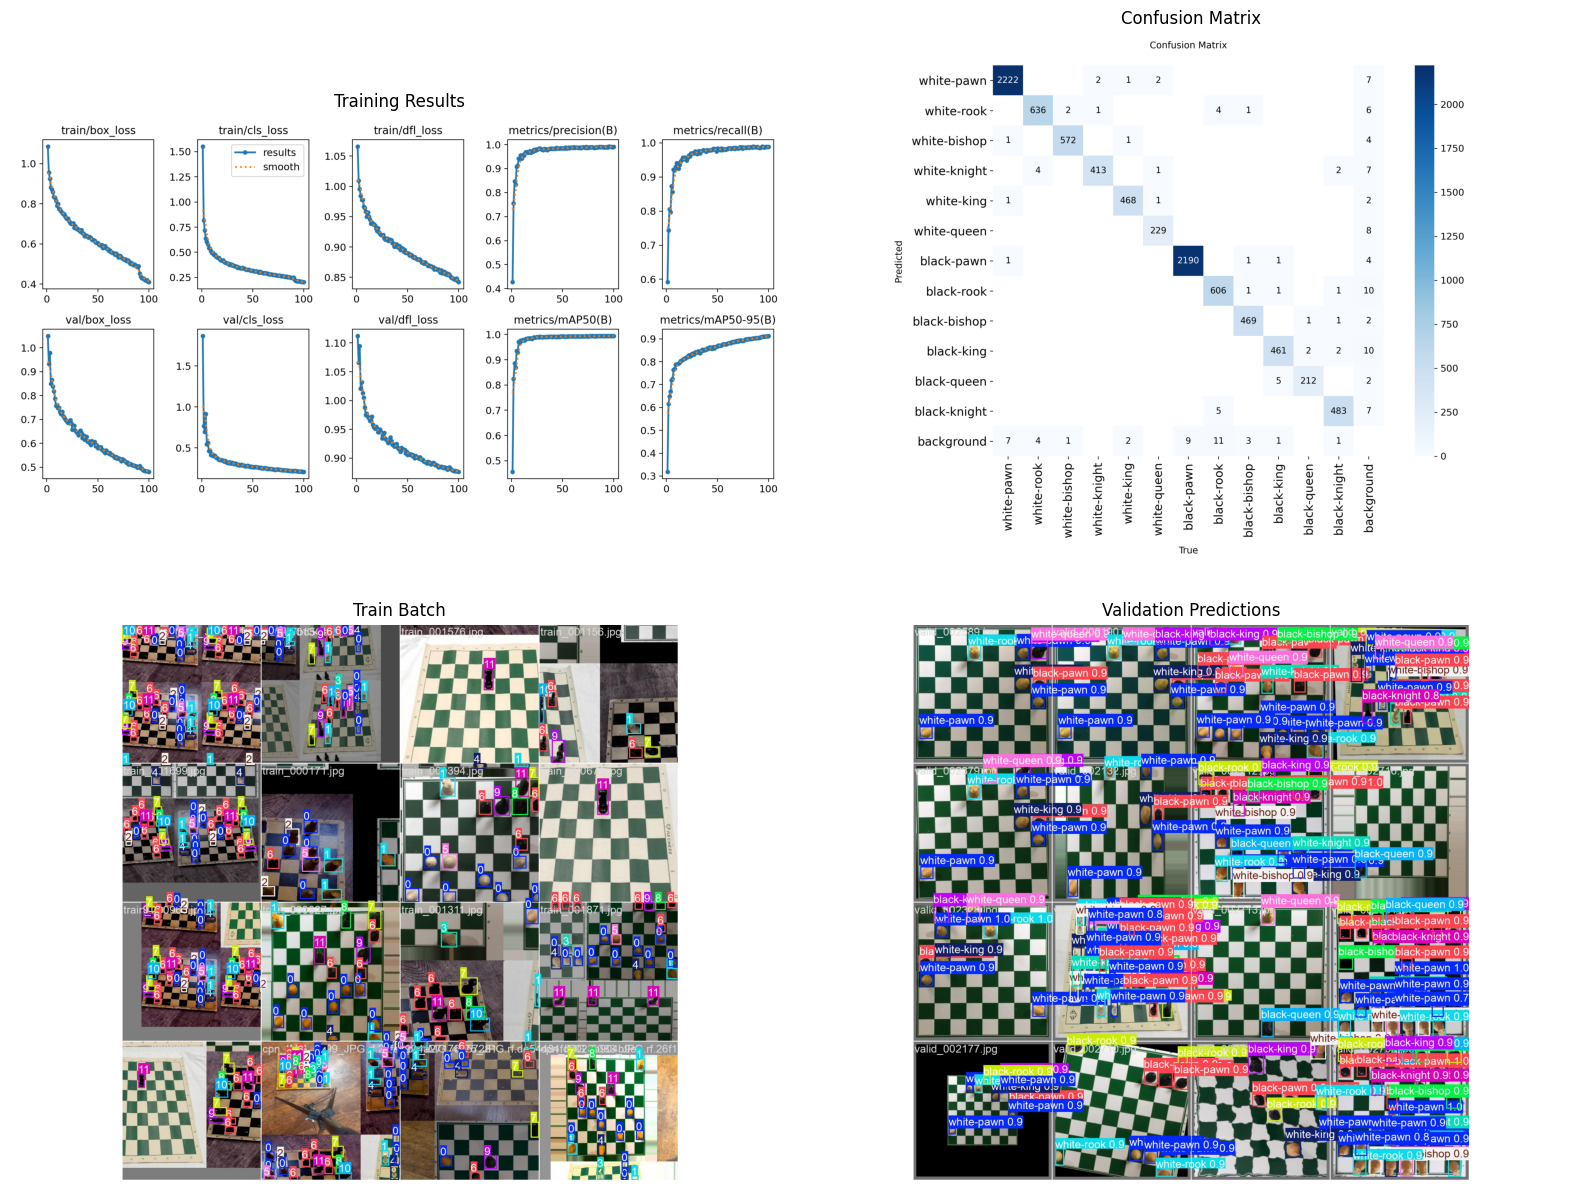


Последние метрики:
    epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
95     96  5525.03         0.42106         0.21011         0.84682   
96     97  5580.65         0.41899         0.20738         0.84574   
97     98  5636.45         0.42006         0.20905         0.84820   
98     99  5692.60         0.41226         0.20609         0.84399   
99    100  5748.39         0.40988         0.20419         0.84207   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
95               0.99252            0.98682           0.99407   
96               0.99049            0.98850           0.99393   
97               0.99059            0.98811           0.99384   
98               0.98983            0.98892           0.99376   
99               0.99055            0.98797           0.99388   

    metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss   lr/pg0  \
95              0.91015       0.48488       0.21032       0.87739  0.00006   
96          

PosixPath('/content/chess_pieces_yolo11/results/chess_pieces_yolo11')

In [11]:
import matplotlib.pyplot as plt
from pathlib import Path

def visualize_training_results(results_dir: Path, run_name: str = 'chess_pieces_yolo11'):
    """Визуализация результатов обучения"""
    results_path = results_dir / run_name

    # Поиск последнего запуска
    if not results_path.exists():
        # Поиск последней директории с результатами
        runs = sorted(results_path.parent.glob('*'), key=lambda x: x.stat().st_mtime, reverse=True)
        if runs:
            results_path = runs[0]
        else:
            print("Результаты обучения не найдены")
            return

    # Загрузка графиков
    results_image = results_path / 'results.png'
    confusion_matrix = results_path / 'confusion_matrix.png'
    train_batch = results_path / 'train_batch0.jpg'
    val_batch = results_path / 'val_batch0_pred.jpg'

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    if results_image.exists():
        img = plt.imread(results_image)
        axes[0, 0].imshow(img)
        axes[0, 0].axis('off')
        axes[0, 0].set_title('Training Results')

    if confusion_matrix.exists():
        img = plt.imread(confusion_matrix)
        axes[0, 1].imshow(img)
        axes[0, 1].axis('off')
        axes[0, 1].set_title('Confusion Matrix')

    if train_batch.exists():
        img = plt.imread(train_batch)
        axes[1, 0].imshow(img)
        axes[1, 0].axis('off')
        axes[1, 0].set_title('Train Batch')

    if val_batch.exists():
        img = plt.imread(val_batch)
        axes[1, 1].imshow(img)
        axes[1, 1].axis('off')
        axes[1, 1].set_title('Validation Predictions')

    plt.tight_layout()
    plt.show()

    # Вывод метрик
    metrics_file = results_path / 'results.csv'
    if metrics_file.exists():
        import pandas as pd
        df = pd.read_csv(metrics_file)
        print("\nПоследние метрики:")
        print(df.tail())

    return results_path

# Визуализация результатов обучения
visualize_training_results(RESULTS_DIR)


## Тестирование лучшей модели на тестовом наборе


In [12]:
def test_best_model_on_test_set(
    results_dir: Path = RESULTS_DIR,
    dataset_dir: Path = DATASET_DIR,
    run_name: str = 'chess_pieces_yolo11',
    conf_threshold: float = 0.25
):
    """
    Тестирование лучшей модели на ВСЕХ изображениях тестового набора
    с выводом метрик ошибок и статистики

    Args:
        results_dir: Директория с результатами обучения
        dataset_dir: Директория с датасетом
        run_name: Имя запуска обучения
        conf_threshold: Порог уверенности
    """
    print("="*60)
    print("ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ НА ТЕСТОВОМ НАБОРЕ")
    print("="*60)

    # Загрузка лучшей модели
    results_path = results_dir / run_name
    if not results_path.exists():
        runs = sorted(results_dir.glob(f'{run_name}*'), key=lambda x: x.stat().st_mtime, reverse=True)
        if runs:
            results_path = runs[0]
            print(f"Найдена директория запуска: {results_path}")
        else:
            raise FileNotFoundError("Результаты обучения не найдены")

    best_model_path = results_path / 'weights' / 'best.pt'
    if not best_model_path.exists():
        raise FileNotFoundError(f"Лучшая модель не найдена: {best_model_path}")

    model = YOLO(str(best_model_path))
    print(f"✓ Модель загружена: {best_model_path}")
    print(f"✓ Классы модели: {len(model.names)}")

    # Тестовый набор (или валидационный, если test нет)
    test_images_dir = dataset_dir / 'test' / 'images'
    test_labels_dir = dataset_dir / 'test' / 'labels'

    # Если test нет, используем valid (если есть)
    if not test_images_dir.exists():
        test_images_dir = dataset_dir / 'valid' / 'images'
        test_labels_dir = dataset_dir / 'valid' / 'labels'
        dataset_name = "валидационном"
    else:
        dataset_name = "тестовом"

    if not test_images_dir.exists():
        raise FileNotFoundError(f"Тестовая/валидационная директория не найдена: {test_images_dir}")

    # Получаем ВСЕ изображения из тестового набора
    image_files = sorted(list(test_images_dir.glob('*.jpg')) + list(test_images_dir.glob('*.png')))
    if not image_files:
        raise FileNotFoundError("Изображения не найдены в тестовом наборе")

    print(f"\n✓ Тестирование на ВСЕХ {len(image_files)} изображениях из {dataset_name} набора")

    # Статистика
    total_detections = 0
    total_ground_truth = 0
    correct_detections = 0
    false_positives = 0
    false_negatives = 0
    class_stats = {name: {'tp': 0, 'fp': 0, 'fn': 0, 'gt': 0} for name in model.names.values()}
    all_confidences = []

    print(f"\n{'='*60}")
    print("ОБРАБОТКА ИЗОБРАЖЕНИЙ")
    print(f"{'='*60}")

    # Обрабатываем ВСЕ изображения
    for idx, img_path in enumerate(image_files, 1):
        # Предсказание модели
        results = model.predict(
            source=str(img_path),
            conf=conf_threshold,
            verbose=False
        )
        result = results[0]

        # Загрузка ground truth
        label_path = test_labels_dir / (img_path.stem + '.txt')
        ground_truth = []
        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls_id = int(parts[0])
                        ground_truth.append(cls_id)
                        class_name = model.names[cls_id]
                        class_stats[class_name]['gt'] += 1
                        total_ground_truth += 1

        # Обработка предсказаний
        predicted_classes = []
        if result.boxes is not None and len(result.boxes) > 0:
            for box in result.boxes:
                cls_id = int(box.cls)
                conf = float(box.conf)
                class_name = model.names[cls_id]
                predicted_classes.append(cls_id)
                all_confidences.append(conf)
                total_detections += 1

                # Проверка правильности (упрощенная: считаем правильным если класс есть в GT)
                if cls_id in ground_truth:
                    correct_detections += 1
                    class_stats[class_name]['tp'] += 1
                else:
                    false_positives += 1
                    class_stats[class_name]['fp'] += 1

        # False negatives (классы в GT, но не обнаружены)
        for gt_cls in ground_truth:
            if gt_cls not in predicted_classes:
                false_negatives += 1
                class_name = model.names[gt_cls]
                class_stats[class_name]['fn'] += 1

        # Прогресс
        if idx % 10 == 0 or idx == len(image_files):
            print(f"Обработано: {idx}/{len(image_files)}")

    # Вывод статистики
    print(f"\n{'='*60}")
    print("СТАТИСТИКА ТЕСТИРОВАНИЯ")
    print(f"{'='*60}")
    print(f"Всего изображений протестировано: {len(image_files)}")
    print(f"Всего обнаружено фигур: {total_detections}")
    print(f"Всего фигур в ground truth: {total_ground_truth}")
    print(f"\nПравильные детекции (TP): {correct_detections}")
    print(f"Ложные срабатывания (FP): {false_positives}")
    print(f"Пропущенные фигуры (FN): {false_negatives}")

    # Метрики
    precision = correct_detections / total_detections if total_detections > 0 else 0
    recall = correct_detections / total_ground_truth if total_ground_truth > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    error_rate = (false_positives + false_negatives) / total_ground_truth if total_ground_truth > 0 else 0

    print(f"\n{'='*60}")
    print("МЕТРИКИ КАЧЕСТВА")
    print(f"{'='*60}")
    print(f"Precision (точность): {precision:.3f} ({precision*100:.1f}%)")
    print(f"Recall (полнота): {recall:.3f} ({recall*100:.1f}%)")
    print(f"F1-Score: {f1_score:.3f}")
    print(f"Процент ошибок: {error_rate:.3f} ({error_rate*100:.1f}%)")

    if all_confidences:
        print(f"\nУверенность модели:")
        print(f"  Средняя: {sum(all_confidences) / len(all_confidences):.3f}")
        print(f"  Минимальная: {min(all_confidences):.3f}")
        print(f"  Максимальная: {max(all_confidences):.3f}")

    # Статистика по классам
    print(f"\n{'='*60}")
    print("СТАТИСТИКА ПО КЛАССАМ")
    print(f"{'='*60}")
    print(f"{'Класс':<20} {'TP':<6} {'FP':<6} {'FN':<6} {'GT':<6} {'Precision':<10} {'Recall':<10} {'F1':<8}")
    print(f"{'-'*80}")

    for class_name in sorted(class_stats.keys()):
        stats = class_stats[class_name]
        if stats['gt'] > 0 or stats['tp'] > 0 or stats['fp'] > 0:
            tp, fp, fn, gt = stats['tp'], stats['fp'], stats['fn'], stats['gt']
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0
            rec = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
            print(f"{class_name:<20} {tp:<6} {fp:<6} {fn:<6} {gt:<6} {prec:<10.3f} {rec:<10.3f} {f1:<8.3f}")

    # Дополнительная статистика
    print(f"\n{'='*60}")
    print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА")
    print(f"{'='*60}")

    # Классы с наибольшим количеством ошибок
    error_by_class = {}
    for class_name, stats in class_stats.items():
        if stats['gt'] > 0 or stats['tp'] > 0 or stats['fp'] > 0:
            tp, fp, fn, gt = stats['tp'], stats['fp'], stats['fn'], stats['gt']
            total_errors = fp + fn
            error_by_class[class_name] = {
                'errors': total_errors,
                'fp': fp,
                'fn': fn,
                'gt': gt,
                'error_rate': total_errors / (gt + fp) if (gt + fp) > 0 else 0
            }

    if error_by_class:
        print(f"\nКлассы с наибольшим количеством ошибок:")
        sorted_errors = sorted(error_by_class.items(), key=lambda x: x[1]['errors'], reverse=True)
        for class_name, err_stats in sorted_errors[:5]:
            print(f"  {class_name:20s}: {err_stats['errors']:3d} ошибок (FP: {err_stats['fp']:3d}, FN: {err_stats['fn']:3d}), "
                  f"ошибок: {err_stats['error_rate']*100:5.1f}%")

    print(f"\n{'='*60}")
    print("ТЕСТИРОВАНИЕ ЗАВЕРШЕНО")
    print(f"{'='*60}")

    return {
        'model': model,
        'model_path': str(best_model_path),
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'error_rate': error_rate,
        'total_detections': total_detections,
        'total_ground_truth': total_ground_truth,
        'correct_detections': correct_detections,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'class_stats': class_stats,
        'total_images': len(image_files)
    }

# Запуск тестирования на всех изображениях тестового набора
test_results = test_best_model_on_test_set(
    results_dir=RESULTS_DIR,
    dataset_dir=DATASET_DIR,
    conf_threshold=0.25
)


ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ НА ТЕСТОВОМ НАБОРЕ
✓ Модель загружена: /content/chess_pieces_yolo11/results/chess_pieces_yolo11/weights/best.pt
✓ Классы модели: 12

✓ Тестирование на ВСЕХ 312 изображениях из тестовом набора

ОБРАБОТКА ИЗОБРАЖЕНИЙ
Обработано: 10/312
Обработано: 20/312
Обработано: 30/312
Обработано: 40/312
Обработано: 50/312
Обработано: 60/312
Обработано: 70/312
Обработано: 80/312
Обработано: 90/312
Обработано: 100/312
Обработано: 110/312
Обработано: 120/312
Обработано: 130/312
Обработано: 140/312
Обработано: 150/312
Обработано: 160/312
Обработано: 170/312
Обработано: 180/312
Обработано: 190/312
Обработано: 200/312
Обработано: 210/312
Обработано: 220/312
Обработано: 230/312
Обработано: 240/312
Обработано: 250/312
Обработано: 260/312
Обработано: 270/312
Обработано: 280/312
Обработано: 290/312
Обработано: 300/312
Обработано: 310/312
Обработано: 312/312

СТАТИСТИКА ТЕСТИРОВАНИЯ
Всего изображений протестировано: 312
Всего обнаружено фигур: 4434
Всего фигур в ground truth: 4449

П

In [17]:
# Бенчмарк скорости модели
# Запускайте после тестирования, чтобы измерить скорость работы модели

# Автоматический поиск лучшей модели
results_path = RESULTS_DIR / 'chess_pieces_yolo11'
if not results_path.exists():
    runs = sorted(RESULTS_DIR.glob('chess_pieces_yolo11*'), key=lambda x: x.stat().st_mtime, reverse=True)
    if runs:
        results_path = runs[0]
        print(f"Найдена директория запуска: {results_path}")
    else:
        raise FileNotFoundError("Результаты обучения не найдены")

best_model_path = results_path / 'weights' / 'best.pt'
if not best_model_path.exists():
    raise FileNotFoundError(f"Лучшая модель не найдена: {best_model_path}")

print(f"Бенчмарк модели: {best_model_path}\n")

benchmark_model_speed(
    model_path=str(best_model_path),
    dataset_dir=DATASET_DIR,
    num_images=50,  # Количество изображений для тестирования скорости
    conf_threshold=0.25
)


Бенчмарк модели: /content/chess_pieces_yolo11/results/chess_pieces_yolo11/weights/best.pt

Бенчмарк на 50 изображениях...

РЕЗУЛЬТАТЫ БЕНЧМАРКА
Среднее время на изображение: 13.09 мс
  Preprocess: 1.95 мс
  Inference: 10.04 мс
  Postprocess: 1.10 мс

FPS: 76.4


In [15]:
def benchmark_model_speed(
    model_path: str,
    dataset_dir: Path,
    num_images: int = 50,
    conf_threshold: float = 0.25
):
    """Измерение скорости работы модели"""
    from ultralytics import YOLO
    import time

    model = YOLO(model_path)
    # Используем test набор, если есть, иначе valid
    test_images_dir = dataset_dir / 'test' / 'images'
    if not test_images_dir.exists():
        test_images_dir = dataset_dir / 'valid' / 'images'

    if not test_images_dir.exists():
        raise FileNotFoundError(f"Тестовая/валидационная директория не найдена")

    image_files = sorted(list(test_images_dir.glob('*.jpg')) + list(test_images_dir.glob('*.png')))[:num_images]

    inference_times = []
    preprocess_times = []
    postprocess_times = []

    print(f"Бенчмарк на {len(image_files)} изображениях...")

    for img_path in image_files:
        results = model.predict(
            source=str(img_path),
            conf=conf_threshold,
            verbose=False
        )
        result = results[0]

        if hasattr(result, 'speed') and result.speed:
            speed = result.speed
            preprocess_times.append(speed.get('preprocess', 0))
            inference_times.append(speed.get('inference', 0))
            postprocess_times.append(speed.get('postprocess', 0))

    if inference_times:
        avg_preprocess = sum(preprocess_times) / len(preprocess_times)
        avg_inference = sum(inference_times) / len(inference_times)
        avg_postprocess = sum(postprocess_times) / len(postprocess_times)
        avg_total = avg_preprocess + avg_inference + avg_postprocess

        print(f"\n{'='*60}")
        print("РЕЗУЛЬТАТЫ БЕНЧМАРКА")
        print(f"{'='*60}")
        print(f"Среднее время на изображение: {avg_total:.2f} мс")
        print(f"  Preprocess: {avg_preprocess:.2f} мс")
        print(f"  Inference: {avg_inference:.2f} мс")
        print(f"  Postprocess: {avg_postprocess:.2f} мс")
        print(f"\nFPS: {1000 / avg_total:.1f}")
        print(f"{'='*60}")

In [16]:
# Тестирование модели bestmerged.pt на выбранном изображении
from ultralytics import YOLO
from pathlib import Path
from PIL import Image
import tkinter as tk
from tkinter import filedialog
import IPython.display as display
import numpy as np
import cv2

def test_bestmerged_model():
    """
    Тестирование модели bestmerged.pt на изображении, выбранном через проводник
    """
    # Загрузка модели
    model_path = Path('bestmerged.pt')
    if not model_path.exists():
        print(f"❌ Модель не найдена: {model_path}")
        print("Убедитесь, что файл bestmerged.pt находится в текущей директории")
        return

    print(f"✓ Загрузка модели: {model_path}")
    model = YOLO(str(model_path))
    print(f"✓ Модель загружена успешно")
    print(f"✓ Классы модели: {len(model.names)}")
    print(f"✓ Классы: {list(model.names.values())}\n")

    # Выбор файла через проводник
    root = tk.Tk()
    root.withdraw()  # Скрываем главное окно
    root.attributes('-topmost', True)  # Поверх всех окон

    file_path = filedialog.askopenfilename(
        title="Выберите изображение для тестирования",
        filetypes=[
            ("Изображения", "*.jpg *.jpeg *.png *.bmp *.gif"),
            ("Все файлы", "*.*")
        ]
    )

    root.destroy()

    if not file_path:
        print("❌ Файл не выбран")
        return

    print(f"✓ Выбран файл: {file_path}\n")

    # Предсказание
    print("="*60)
    print("ВЫПОЛНЕНИЕ ПРЕДСКАЗАНИЯ")
    print("="*60)

    results = model.predict(
        source=file_path,
        conf=0.25,  # Порог уверенности
        iou=0.45,   # Порог IoU для NMS
        verbose=True
    )

    result = results[0]

    # Обработка результатов
    detections_count = 0
    if result.boxes is not None and len(result.boxes) > 0:
        print(f"\n✓ Найдено детекций: {len(result.boxes)}\n")

        for i, box in enumerate(result.boxes):
            # Координаты bbox
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

            # Класс и уверенность
            cls_id = int(box.cls)
            conf = float(box.conf)
            class_name = model.names[cls_id]

            detections_count += 1

            print(f"  {detections_count}. {class_name:20s} уверенность: {conf:.3f}  bbox: ({x1}, {y1}, {x2}, {y2})")
    else:
        print("\n❌ Детекций не найдено")

    # Статистика
    print("\n" + "="*60)
    print("СТАТИСТИКА")
    print("="*60)
    print(f"Всего детекций: {detections_count}")

    if detections_count > 0:
        # Подсчет по классам
        class_counts = {}
        for box in result.boxes:
            cls_id = int(box.cls)
            class_name = model.names[cls_id]
            class_counts[class_name] = class_counts.get(class_name, 0) + 1

        print("\nДетекции по классам:")
        for class_name, count in sorted(class_counts.items()):
            print(f"  {class_name:20s}: {count}")

    # Визуализация результатов с исправлением цветов и кастомизацией
    print("\n" + "="*60)
    print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
    print("="*60)

    # Создаем свою функцию для рисования с тонкими линиями и маленькими подписями
    def custom_visualize(image, boxes, classes, model):
        """
        Кастомизированная визуализация с тонкими линиями и маленькими подписями
        """
        # Копируем изображение, чтобы не изменять оригинал
        img_copy = image.copy()

        # Получаем размеры изображения для масштабирования толщины линии и шрифта
        height, width = img_copy.shape[:2]
        line_thickness = max(1, int(min(height, width) / 700))  # Тонкие линии
        font_scale = max(0.4, min(height, width) / 3500)  # Маленький шрифт

        for i, box in enumerate(boxes):
            # Координаты bbox
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

            # Класс и уверенность
            cls_id = int(box.cls)
            conf = float(box.conf)
            class_name = model.names[cls_id]

            # Генерация цвета на основе класса
            color = (
                int((hash(class_name) % 256)),
                int((hash(class_name) * 7 % 256)),
                int((hash(class_name) * 13 % 256))
            )

            # Рисуем тонкий прямоугольник
            cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, line_thickness)

            # Создаем подпись с маленьким шрифтом
            label = f"{class_name}: {conf:.2f}"

            # Вычисляем размер текста
            (text_width, text_height), baseline = cv2.getTextSize(
                label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, line_thickness
            )

            # Рисуем фон для текста
            cv2.rectangle(
                img_copy,
                (x1, y1 - text_height - baseline - 5),
                (x1 + text_width, y1),
                color,
                -1  # Заливка
            )

            # Рисуем текст
            cv2.putText(
                img_copy,
                label,
                (x1, y1 - baseline - 3),
                cv2.FONT_HERSHEY_SIMPLEX,
                font_scale,
                (255, 255, 255),  # Белый текст
                line_thickness,
                cv2.LINE_AA
            )

        return img_copy

    # Альтернативный вариант: используем plot() с кастомизацией через параметры
    if result.boxes is not None and len(result.boxes) > 0:
        # Загружаем оригинальное изображение
        orig_img = cv2.imread(file_path)

        # Используем кастомизированную визуализацию
        annotated_img = custom_visualize(orig_img, result.boxes, result.names, model)
    else:
        # Если детекций нет, просто загружаем изображение
        annotated_img = cv2.imread(file_path)

    # Конвертируем BGR (OpenCV) в RGB (PIL/Matplotlib)
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    # Конвертируем в PIL Image
    annotated_pil = Image.fromarray(annotated_img_rgb)

    # Отображение изображения в ноутбуке
    display.display(annotated_pil)

    print("\n" + "="*60)
    print("ТЕСТИРОВАНИЕ ЗАВЕРШЕНО")
    print("="*60)

# Запуск тестирования
test_bestmerged_model()

❌ Модель не найдена: bestmerged.pt
Убедитесь, что файл bestmerged.pt находится в текущей директории
